# 04 — TCGA Preprocessing

This notebook cleans the raw merged TCGA dataset and produces a model-ready feature matrix.

> **Prerequisite**: run `02_tcga_data_loading.ipynb` first.

---

## Pipeline overview

| Step | What | Why |
|------|------|-----|
| 1 | Remove duplicate patients | Barcode truncation can create row dupes |
| 2 | Log-transform expression | RSEM values are right-skewed; log₂(x+1) stabilises variance |
| 3 | Drop zero-expression genes | All-zero columns carry no signal |
| 4 | CV-based gene filter | Remove near-constant genes (bottom 10th percentile by CV) |
| 5 | Fill remaining NaNs | Missing RSEM → 0 (unexpressed) |
| 6 | Harmonise multi-class labels | Collapse rare/ambiguous Variant_Classification values |
| 7 | Save | `data/processed/tcga_preprocessed.csv.gz` |


## Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DIR = Path("../data/processed")

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
IN_FILE = PROCESSED_DIR / "tcga_merged_raw.csv.gz"
assert IN_FILE.exists(), f"Missing: {IN_FILE} — run notebook 02 first."

print("Loading merged dataset...")
df = pd.read_csv(IN_FILE, index_col=0, low_memory=False)

LABEL_COLS = ['Mutated', 'Variant_Classification']
gene_cols  = [c for c in df.columns if c not in LABEL_COLS]

print(f"Input shape: {df.shape[0]:,} patients × {len(gene_cols):,} genes + {len(LABEL_COLS)} labels")

Loading merged dataset...
Input shape: 9,875 patients × 20,501 genes + 2 labels


---

## Step 1 — Remove duplicate patients

In [3]:
n_dupes = df.index.duplicated().sum()
print(f"Duplicate patient IDs: {n_dupes:,}")

if n_dupes > 0:
    df = df[~df.index.duplicated(keep='first')]
    print(f"Shape after dedup: {df.shape}")
else:
    print("No duplicates — no rows dropped.")

Duplicate patient IDs: 0
No duplicates — no rows dropped.


---

## Step 2 — Log-transform expression

The TCGA PANCAN EB++ file contains raw RSEM values (unlike CCLE's already-logged TPM). We apply log₂(x + 1) to compress the dynamic range and approach normality.

In [4]:
X_raw = df[gene_cols]

# Confirm no negative values (RSEM is always ≥ 0)
neg_count = (X_raw < 0).sum().sum()
if neg_count > 0:
    print(f"WARNING: {neg_count:,} negative RSEM values found — investigate before transforming.")
else:
    print("All RSEM values ≥ 0. Applying log₂(x + 1)...")

X_log = np.log2(X_raw.fillna(0) + 1)

print(f"log-transformed range: [{X_log.values.min():.3f}, {X_log.values.max():.3f}]")

log-transformed range: [-6.830, 22.758]


---

## Step 3 — Remove zero-expression genes

Genes with zero expression across every sample contribute no information.

In [5]:
gene_sums = X_log.sum(axis=0)
zero_mask = gene_sums == 0

print(f"Zero-expression genes: {zero_mask.sum():,} / {len(zero_mask):,}")

X_log = X_log.loc[:, ~zero_mask]
print(f"Genes remaining: {X_log.shape[1]:,}")

Zero-expression genes: 220 / 20,501
Genes remaining: 20,281


---

## Step 4 — CV-based gene filter

Remove genes in the bottom 10th percentile by coefficient of variation. These genes are nearly constant across all patients and unlikely to be informative predictors.

In [6]:
gene_cv = X_log.std(axis=0) / (X_log.mean(axis=0) + 1e-9)

cv_threshold = gene_cv.quantile(0.10)
print(f"CV 10th-percentile threshold: {cv_threshold:.4f}")

high_cv_mask = gene_cv >= cv_threshold
X_filt = X_log.loc[:, high_cv_mask]

print(f"Genes before CV filter : {X_log.shape[1]:,}")
print(f"Genes after  CV filter : {X_filt.shape[1]:,}  (removed {(~high_cv_mask).sum():,})") 

CV 10th-percentile threshold: 0.0604
Genes before CV filter : 20,281
Genes after  CV filter : 18,253  (removed 2,028)


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_2640/2930622539.py:9: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/elizabeth/opt/anaconda3/envs/tp53-predictor/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


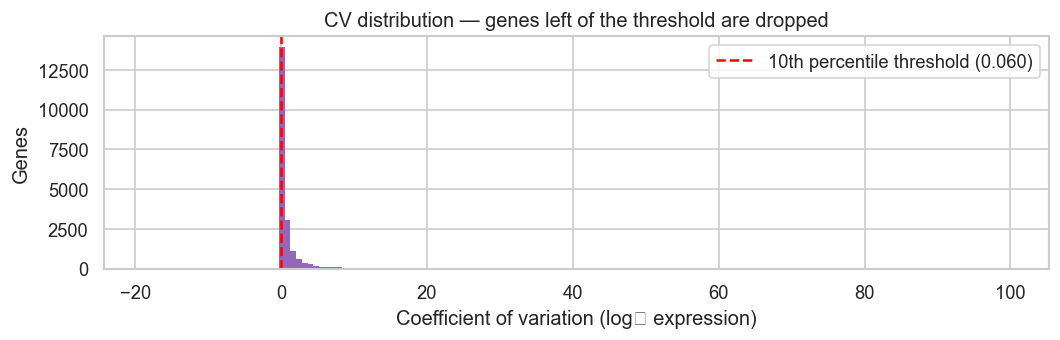

In [7]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(gene_cv, bins=150, color='#9467BD', edgecolor='none')
ax.axvline(cv_threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'10th percentile threshold ({cv_threshold:.3f})')
ax.set_xlabel('Coefficient of variation (log₂ expression)')
ax.set_ylabel('Genes')
ax.set_title('CV distribution — genes left of the threshold are dropped')
ax.legend()
plt.tight_layout()
plt.show()

---

## Step 5 — Fill remaining NaNs

If any NaN values remain after the zero-expression filter, fill with 0 (a missing RSEM value means the gene was not detected, equivalent to no expression).

In [8]:
nan_remaining = X_filt.isnull().sum().sum()
print(f"NaN values before fill: {nan_remaining:,}")

if nan_remaining > 0:
    X_filt = X_filt.fillna(0)
    print("Filled with 0.")
else:
    print("No NaNs — nothing to fill.")

NaN values before fill: 0
No NaNs — nothing to fill.


---

## Step 6 — Harmonise multi-class labels

The raw `Variant_Classification` column contains MAF-standard categories. We map these to a cleaner set of labels:

| Raw classification(s) | Final label |
|-----------------------|-------------|
| `Missense_Mutation` | `Missense` |
| `Frame_Shift_Del`, `Frame_Shift_Ins` | `Frameshift` |
| `Nonsense_Mutation` | `Nonsense` |
| `Splice_Site` | `Splice` |
| `In_Frame_Del`, `In_Frame_Ins` | `InFrame` |
| `Silent`, `RNA`, `3'UTR`, `5'UTR`, `Intron`, … | `Other` |
| `WT` | `WT` |

`Other` groups functionally ambiguous mutations. Modeling notebooks can decide whether to keep them or drop them.

In [9]:
CLASS_MAP = {
    'Missense_Mutation':         'Missense',
    'Frame_Shift_Del':           'Frameshift',
    'Frame_Shift_Ins':           'Frameshift',
    'Nonsense_Mutation':         'Nonsense',
    'Splice_Site':               'Splice',
    'In_Frame_Del':              'InFrame',
    'In_Frame_Ins':              'InFrame',
    'Translation_Start_Site':    'Other',
    'Nonstop_Mutation':          'Other',
    'Silent':                    'Other',
    'RNA':                       'Other',
    "3'UTR":                     'Other',
    "5'UTR":                     'Other',
    "3'Flank":                   'Other',
    "5'Flank":                   'Other',
    'Intron':                    'Other',
    'IGR':                       'Other',
    'WT':                        'WT',
}

raw_classes = df['Variant_Classification'].unique()
print("Raw classes found:")
print(sorted(raw_classes))

df_proc = df.copy()
df_proc['Mutation_Class'] = df_proc['Variant_Classification'].map(CLASS_MAP)

# Any class not in the map → 'Other'
def_count = df_proc['Mutation_Class'].isnull().sum()
if def_count > 0:
    unmapped = df_proc.loc[df_proc['Mutation_Class'].isnull(), 'Variant_Classification'].unique()
    print(f"\n{def_count} unmapped values (→ Other): {unmapped}")
    df_proc['Mutation_Class'] = df_proc['Mutation_Class'].fillna('Other')

print("\nMutation_Class distribution:")
print(df_proc['Mutation_Class'].value_counts().to_string())

Raw classes found:
["3'UTR", "5'UTR", 'Frame_Shift_Del', 'Frame_Shift_Ins', 'In_Frame_Del', 'In_Frame_Ins', 'Intron', 'Missense_Mutation', 'Nonsense_Mutation', 'Silent', 'Splice_Site', 'WT']

Mutation_Class distribution:
Mutation_Class
WT            6744
Missense      1949
Nonsense       452
Frameshift     394
Splice         215
InFrame         68
Other           53


---

## Step 7 — Assemble final dataset

In [10]:
# Combine filtered expression with label columns
final_label_cols = ['Mutated', 'Variant_Classification', 'Mutation_Class']
final_df = pd.concat([
    X_filt,
    df_proc[final_label_cols]
], axis=1)

print(f"Final dataset shape: {final_df.shape[0]:,} patients × {final_df.shape[1]:,} columns")
print(f"  Expression features : {X_filt.shape[1]:,}")
print(f"  Label columns       : {len(final_label_cols)}")

# Confirm no NaNs in expression
assert final_df[X_filt.columns].isnull().sum().sum() == 0, "NaN values remain in expression!"
print("\nNo NaN values in expression columns.")

Final dataset shape: 9,875 patients × 18,256 columns
  Expression features : 18,253
  Label columns       : 3

No NaN values in expression columns.


---

## Summary: before vs. after

In [11]:
raw_genes    = len(gene_cols)
final_genes  = X_filt.shape[1]
raw_patients = df.shape[0]
final_patients = final_df.shape[0]

print("=" * 55)
print(f"{'':30s} {'Before':>10s}  {'After':>10s}")
print("-" * 55)
print(f"{'Patients':30s} {raw_patients:>10,}  {final_patients:>10,}")
print(f"{'Genes':30s} {raw_genes:>10,}  {final_genes:>10,}")
print("-" * 55)
print("Binary label distribution:")
print(final_df['Mutated'].value_counts().rename({0:'WT', 1:'Mutated'}).to_string())
print("\nMulti-class label distribution:")
print(final_df['Mutation_Class'].value_counts().to_string())
print("=" * 55)

                                   Before       After
-------------------------------------------------------
Patients                            9,875       9,875
Genes                              20,501      18,253
-------------------------------------------------------
Binary label distribution:
Mutated
WT         6744
Mutated    3131

Multi-class label distribution:
Mutation_Class
WT            6744
Missense      1949
Nonsense       452
Frameshift     394
Splice         215
InFrame         68
Other           53


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_2640/1378577004.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(counts_mut.index, rotation=20, ha='right')


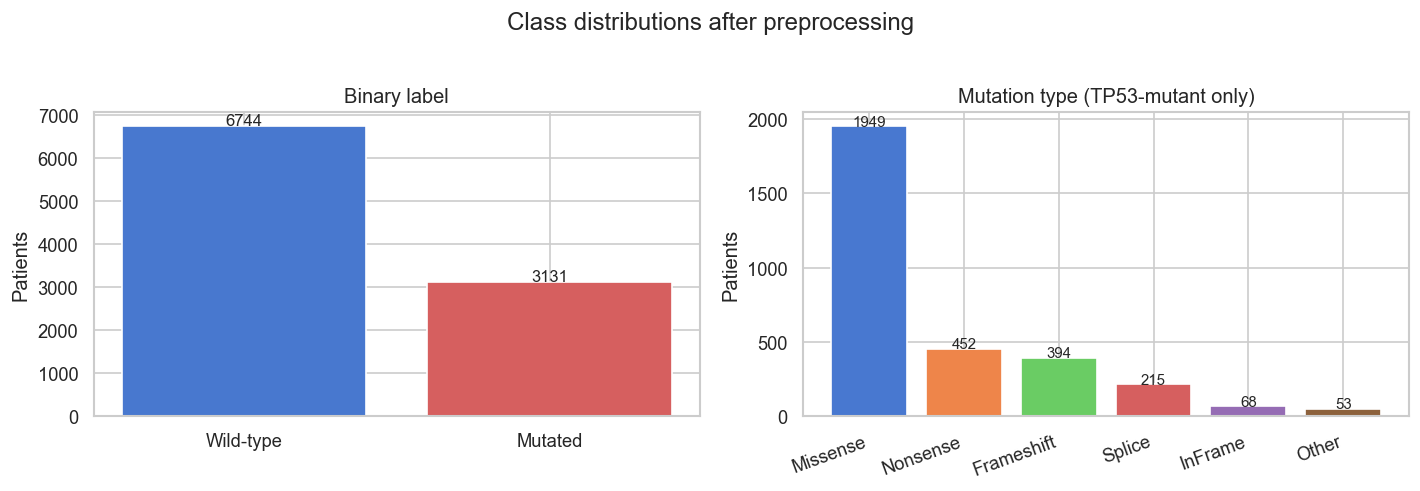

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Binary
counts_bin = final_df['Mutated'].value_counts().rename({0: 'Wild-type', 1: 'Mutated'})
axes[0].bar(counts_bin.index, counts_bin.values, color=['#4878CF', '#D65F5F'], edgecolor='white')
for i, v in enumerate(counts_bin.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)
axes[0].set_title('Binary label')
axes[0].set_ylabel('Patients')

# Multi-class (exclude WT for clarity)
counts_mut = final_df[final_df['Mutation_Class'] != 'WT']['Mutation_Class'].value_counts()
colors = sns.color_palette('muted', len(counts_mut))
axes[1].bar(counts_mut.index, counts_mut.values, color=colors, edgecolor='white')
for i, v in enumerate(counts_mut.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)
axes[1].set_title('Mutation type (TP53-mutant only)')
axes[1].set_ylabel('Patients')
axes[1].set_xticklabels(counts_mut.index, rotation=20, ha='right')

plt.suptitle('Class distributions after preprocessing', y=1.02)
plt.tight_layout()
plt.show()

---

## Save

In [13]:
OUT_FILE = PROCESSED_DIR / "tcga_preprocessed.csv.gz"
print(f"Saving to {OUT_FILE} ...")
final_df.to_csv(OUT_FILE, compression='gzip')
print(f"Done. File size: {OUT_FILE.stat().st_size / 1e6:.1f} MB")

Saving to ../data/processed/tcga_preprocessed.csv.gz ...
Done. File size: 1035.6 MB


---

## Notes for modeling

- **Expression features** are log₂(RSEM+1), zero-mean standardisation is NOT applied here — do it inside model pipelines using `StandardScaler` to avoid data leakage.
- **Class imbalance**: both binary and multi-class targets are imbalanced. Recommended approaches:
  - Binary: `class_weight='balanced'` in sklearn estimators, or SMOTE on training fold only.
  - Multi-class: SMOTE or class weights; consider dropping the `Other` category or treating it as WT.
- **`Variant_Classification`** (raw MAF string) is retained alongside `Mutation_Class` for reference. Drop `Variant_Classification` before passing `X` to any model.
- **Feature scaling**: apply `StandardScaler` inside cross-validation folds to prevent leakage.